# ============================================================
# ANALYSIS 1: Power Spectral Density (PSD) & 1/f^alpha Falloff
# ============================================================
#
# PURPOSE: Quantify the spectral slope (alpha) of images in 4 groups
# and show that SPAI's spectral assumptions break down for medical images.
#
# KAGGLE SETUP — 3 datasets to add (all via "Add Data" button, no upload needed for natural):
#   1. Custom medical dataset   → already uploaded as "pairwise-medical-dataset"
#   2. COCO 2017              → search "coco-2017-dataset" by awsaf49  (Add Data → search)
#   3. CIFAKE                 → search "cifake-real-and-ai-generated-synthetic-images" by birdy654
#
# CIFAKE uses Stable Diffusion 1.4 which is one of the exact generators
# that the SPAI paper evaluates — making it a perfect match.

# ============================================================

In [5]:
# ===========================================================
# CELL 1: Install dependencies & imports
# ===========================================================
# %%
import subprocess
subprocess.run(["pip", "install", "scipy", "scikit-image", "seaborn", "tqdm", "--quiet"], check=True)

import os
import glob
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image
from scipy import stats
from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

# Quick sanity check — list what datasets are mounted
print("Mounted datasets:")
for d in sorted(os.listdir("/kaggle/input")):
    print(f"  /kaggle/input/{d}")

print("\n✅ All imports successful")

Mounted datasets:
  /kaggle/input/datasets
  /kaggle/input/notebooks

✅ All imports successful


In [6]:
# ===========================================================
# CELL 2: Configure paths — VERIFY THESE MATCH YOUR KAGGLE SETUP
# ===========================================================
# %%
# -----------------------------------------------------------------------
# DATASET 1: Your medical images (uploaded as Kaggle dataset)
#
# Real X-rays structure:
#   original_images/
#     1/   ← patient folder
#       1_IM-0001-3001.dcm.png  (Lateral view)
#       1_IM-0001-4001.dcm.png  (Frontal view)
#     2/   ← patient folder
#       ...
#     101/ ← up to 101 patients
#
# NOTE: collect_image_paths() uses recursive glob so it automatically
# finds images inside these numbered subfolders.
# Expected total: ~202 real images (101 patients × ~2 views each)
#
# Synthetic X-rays structure (flat — no subfolders):
#   synthetic_images/
#     1_PA.png
#     1_Lateral.png
#     2_PA.png
#     ...  (~194 images total)
# -----------------------------------------------------------------------
MEDICAL_REAL_DIR      = "/kaggle/input/datasets/kashshaflabib/pairwise-medical-dataset/verification_data/original_images"
MEDICAL_SYNTHETIC_DIR = "/kaggle/input/datasets/kashshaflabib/pairwise-medical-dataset/verification_data/synthetic_images"

# -----------------------------------------------------------------------
# DATASET 2: COCO 2017 (real natural images)
# Add via: Add Data → search "coco-2017-dataset" (by awsaf49)
# Contains val2017/ with 5,000 natural photographs
# -----------------------------------------------------------------------
NATURAL_REAL_DIR = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017"

# -----------------------------------------------------------------------
# DATASET 3: CIFAKE (AI-generated natural images via Stable Diffusion 1.4)
# Add via: Add Data → search "cifake-real-and-ai-generated-synthetic-images" (by birdy654)
# Contains test/FAKE/ and train/FAKE/ with SD 1.4 generated images
# This aligns with SPAI's evaluation on SD 1.4 (fake_sd14.csv)
# -----------------------------------------------------------------------
NATURAL_SYNTHETIC_DIR = "/kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/test/FAKE"

# Output directory
OUTPUT_DIR = "/kaggle/working/analysis1_psd"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Sampling — how many images per group (150 is plenty for statistical power)
N_SAMPLES = 150

# ---- Verify paths exist ----
for label, path in [("Medical Real", MEDICAL_REAL_DIR),
                    ("Medical Synthetic", MEDICAL_SYNTHETIC_DIR),
                    ("Natural Real (COCO)", NATURAL_REAL_DIR),
                    ("Natural Synthetic (CIFAKE)", NATURAL_SYNTHETIC_DIR)]:
    exists = os.path.isdir(path)
    status = "✅" if exists else "❌ NOT FOUND"
    print(f"  {status}  {label}: {path}")

print(f"\n  Output dir: {OUTPUT_DIR}")
print(f"  Sampling {N_SAMPLES} images per group")


  ✅  Medical Real: /kaggle/input/datasets/kashshaflabib/pairwise-medical-dataset/verification_data/original_images
  ✅  Medical Synthetic: /kaggle/input/datasets/kashshaflabib/pairwise-medical-dataset/verification_data/synthetic_images
  ✅  Natural Real (COCO): /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017
  ✅  Natural Synthetic (CIFAKE): /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/test/FAKE

  Output dir: /kaggle/working/analysis1_psd
  Sampling 150 images per group


In [7]:
# ===========================================================
# CELL 3: Collect image paths from all 4 groups
# ===========================================================
# %%
def collect_image_paths(directory, extensions=(".png", ".jpg", ".jpeg"), max_n=None):
    """Recursively collect image paths from a directory."""
    paths = []
    for ext in extensions:
        paths.extend(glob.glob(os.path.join(directory, "**", f"*{ext}"), recursive=True))
        paths.extend(glob.glob(os.path.join(directory, "**", f"*{ext.upper()}"), recursive=True))
    paths = sorted(set(paths))
    random.shuffle(paths)
    if max_n and len(paths) > max_n:
        paths = paths[:max_n]
    return paths

paths_med_real  = collect_image_paths(MEDICAL_REAL_DIR,      max_n=N_SAMPLES)
paths_med_fake  = collect_image_paths(MEDICAL_SYNTHETIC_DIR, max_n=N_SAMPLES)
paths_nat_real  = collect_image_paths(NATURAL_REAL_DIR,      max_n=N_SAMPLES)
paths_nat_fake  = collect_image_paths(NATURAL_SYNTHETIC_DIR, max_n=N_SAMPLES)

print("Image counts per group:")
print(f"  Real Medical X-rays         : {len(paths_med_real)}")
print(f"  Synthetic Medical X-rays    : {len(paths_med_fake)}")
print(f"  Real Natural (COCO val2017) : {len(paths_nat_real)}")
print(f"  Synthetic Natural (CIFAKE)  : {len(paths_nat_fake)}")

# Show sample paths for verification
for label, paths in [("Med Real", paths_med_real), ("Med Fake", paths_med_fake),
                     ("Nat Real", paths_nat_real), ("Nat Fake", paths_nat_fake)]:
    if paths:
        print(f"\n  Sample {label}: {paths[0]}")

Image counts per group:
  Real Medical X-rays         : 150
  Synthetic Medical X-rays    : 150
  Real Natural (COCO val2017) : 150
  Synthetic Natural (CIFAKE)  : 150

  Sample Med Real: /kaggle/input/datasets/kashshaflabib/pairwise-medical-dataset/verification_data/original_images/59/59_IM-2184-1001.dcm.png

  Sample Med Fake: /kaggle/input/datasets/kashshaflabib/pairwise-medical-dataset/verification_data/synthetic_images/93_Lateral.png

  Sample Nat Real: /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017/000000041872.jpg

  Sample Nat Fake: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/test/FAKE/151 (2).jpg


In [8]:
# ===========================================================
# CELL 4: Core PSD computation functions
# ===========================================================
# %%
IMG_SIZE = 256   # All images resized to this square before FFT

def load_image_gray(path, size=IMG_SIZE):
    """Load an image as grayscale float [0,1], resized to (size x size)."""
    try:
        img = Image.open(path).convert("L")
        img = img.resize((size, size), Image.LANCZOS)
        return np.array(img, dtype=np.float32) / 255.0
    except Exception as e:
        return None

def compute_radial_psd(img_gray):
    """
    Compute radially-averaged Power Spectral Density (PSD).
    
    For an image I(x,y), we compute:
        F(u,v)  = FFT2(I)                   — 2D Fourier Transform
        P(u,v)  = |F(u,v)|²                 — Power spectrum
        P(f)    = mean(P) over ring f        — Radial average at frequency f
    
    Returns:
        freqs : 1D array of normalized spatial frequencies [0, 0.5]
        psd   : 1D array of mean power at each frequency ring
    """
    H, W = img_gray.shape
    F = np.fft.fft2(img_gray)
    F = np.fft.fftshift(F)
    power = np.abs(F) ** 2

    cy, cx = H // 2, W // 2
    y = np.arange(H) - cy
    x = np.arange(W) - cx
    xx, yy = np.meshgrid(x, y)
    r = np.sqrt(xx**2 + yy**2).astype(int)

    max_r = min(cy, cx)
    psd = np.zeros(max_r)
    for i in range(max_r):
        mask = r == i
        if mask.any():
            psd[i] = power[mask].mean()

    freqs = np.arange(max_r) / (2.0 * max_r)
    return freqs, psd

def fit_power_law(freqs, psd, freq_min=0.02):
    """
    Fit the power law model:   P(f) = C · f^(-α)
    
    In log-log space this becomes:
        log₁₀ P(f) = -α · log₁₀(f) + log₁₀(C)
    
    We fit via linear regression on the log-log data.
    
    Returns: alpha, log_c, r_squared
    """
    mask = freqs > freq_min
    log_f = np.log10(freqs[mask])
    log_p = np.log10(psd[mask] + 1e-10)

    slope, intercept, r_value, p_value, std_err = stats.linregress(log_f, log_p)
    alpha = -slope
    r_sq  = r_value**2
    return alpha, intercept, r_sq

print("✅ PSD functions defined")

✅ PSD functions defined


In [10]:
# ===========================================================
# CELL 5: Compute PSD for all 4 groups (MAIN COMPUTATION ~5-10 min)
# ===========================================================
# %%
# We store PSD curve data separately (not in df.attrs) to avoid
# pandas concat errors when comparing numpy arrays.
psd_curves = {}   # dict of group_name -> {"mean_psd", "std_psd", "freqs"}

def process_group(paths, group_name):
    """Process a list of image paths — compute PSD and fit alpha for each."""
    records = []
    all_psds = []

    for p in tqdm(paths, desc=group_name):
        img = load_image_gray(p, size=IMG_SIZE)
        if img is None:
            continue
        freqs, psd = compute_radial_psd(img)
        alpha, ic, r_sq = fit_power_law(freqs, psd)
        records.append({
            "path": p, "group": group_name,
            "alpha": alpha, "r_sq": r_sq, "log_c": ic,
        })
        all_psds.append(psd)

    df = pd.DataFrame(records)
    psd_curves[group_name] = {
        "mean_psd": np.mean(all_psds, axis=0),
        "std_psd":  np.std(all_psds, axis=0),
        "freqs":    freqs,
    }
    return df

df_nat_real  = process_group(paths_nat_real,  "Real Natural")
df_nat_fake  = process_group(paths_nat_fake,  "Synthetic Natural")
df_med_real  = process_group(paths_med_real,  "Real Medical")
df_med_fake  = process_group(paths_med_fake,  "Synthetic Medical")

df_all = pd.concat([df_nat_real, df_nat_fake, df_med_real, df_med_fake], ignore_index=True)

print("\n" + "=" * 65)
print("α (SPECTRAL SLOPE) SUMMARY PER GROUP")
print("=" * 65)
summary = df_all.groupby("group").agg(
    n          = ("alpha", "count"),
    alpha_mean = ("alpha", "mean"),
    alpha_std  = ("alpha", "std"),
    alpha_min  = ("alpha", "min"),
    alpha_max  = ("alpha", "max"),
    r_sq_mean  = ("r_sq",  "mean"),
).round(4)
print(summary.to_string())
summary.to_csv(f"{OUTPUT_DIR}/alpha_summary.csv")

Real Natural:   0%|          | 0/150 [00:00<?, ?it/s]

Synthetic Natural:   0%|          | 0/150 [00:00<?, ?it/s]

Real Medical:   0%|          | 0/150 [00:00<?, ?it/s]

Synthetic Medical:   0%|          | 0/150 [00:00<?, ?it/s]


α (SPECTRAL SLOPE) SUMMARY PER GROUP
                     n  alpha_mean  alpha_std  alpha_min  alpha_max  r_sq_mean
group                                                                         
Real Medical       150      2.8680     0.1826     2.0175     3.6672     0.9941
Real Natural       150      2.5562     0.2882     1.7770     3.1529     0.9880
Synthetic Medical  150      3.0384     0.1326     2.6936     3.3788     0.9958
Synthetic Natural  150      3.3313     0.2437     2.8173     3.9686     0.9561


In [11]:
# ===========================================================
# CELL 6: Statistical tests — KS test & Cohen's d
# ===========================================================
# %%
def ks_test_report(group_a, group_b, label_a, label_b):
    """Kolmogorov-Smirnov test and Cohen's d effect size."""
    a = group_a["alpha"].dropna().values
    b = group_b["alpha"].dropna().values
    ks_stat, p_val = stats.ks_2samp(a, b)
    pooled_std = np.sqrt((a.std()**2 + b.std()**2) / 2)
    cohens_d = abs(a.mean() - b.mean()) / (pooled_std + 1e-10)
    print(f"\n  {label_a}  vs  {label_b}")
    print(f"    Mean α: {a.mean():.4f} vs {b.mean():.4f}  (Δ = {abs(a.mean()-b.mean()):.4f})")
    print(f"    KS statistic : {ks_stat:.4f}     p-value : {p_val:.4e}")
    print(f"    Cohen's d    : {cohens_d:.4f}     ({'large' if cohens_d>0.8 else 'medium' if cohens_d>0.5 else 'SMALL'} effect)")
    return {"comparison": f"{label_a} vs {label_b}",
            "mean_a": a.mean(), "mean_b": b.mean(),
            "delta_alpha": abs(a.mean() - b.mean()),
            "ks_stat": ks_stat, "p_value": p_val, "cohens_d": cohens_d}

print("=" * 65)
print("STATISTICAL TESTS ON α — Real vs Synthetic, per domain")
print("=" * 65)
results_stats = []

print("\n--- KEY COMPARISON: Can spectral slope distinguish real from fake? ---")
results_stats.append(ks_test_report(df_nat_real, df_nat_fake, "Real Natural",     "Synthetic Natural"))
results_stats.append(ks_test_report(df_med_real, df_med_fake, "Real Medical",     "Synthetic Medical"))

print("\n--- CROSS-DOMAIN: How different are natural vs medical images? ---")
results_stats.append(ks_test_report(df_nat_real, df_med_real, "Real Natural",     "Real Medical"))
results_stats.append(ks_test_report(df_nat_fake, df_med_fake, "Synthetic Natural","Synthetic Medical"))

df_stats = pd.DataFrame(results_stats)
df_stats.to_csv(f"{OUTPUT_DIR}/ks_test_results.csv", index=False)
print(f"\n✅ Saved to {OUTPUT_DIR}/ks_test_results.csv")

STATISTICAL TESTS ON α — Real vs Synthetic, per domain

--- KEY COMPARISON: Can spectral slope distinguish real from fake? ---

  Real Natural  vs  Synthetic Natural
    Mean α: 2.5562 vs 3.3313  (Δ = 0.7751)
    KS statistic : 0.8667     p-value : 1.5999e-58
    Cohen's d    : 2.9142     (large effect)

  Real Medical  vs  Synthetic Medical
    Mean α: 2.8680 vs 3.0384  (Δ = 0.1704)
    KS statistic : 0.5067     p-value : 6.9344e-18
    Cohen's d    : 1.0715     (large effect)

--- CROSS-DOMAIN: How different are natural vs medical images? ---

  Real Natural  vs  Real Medical
    Mean α: 2.5562 vs 2.8680  (Δ = 0.3119)
    KS statistic : 0.5933     p-value : 7.5885e-25
    Cohen's d    : 1.2971     (large effect)

  Synthetic Natural  vs  Synthetic Medical
    Mean α: 3.3313 vs 3.0384  (Δ = 0.2929)
    KS statistic : 0.5867     p-value : 2.9252e-24
    Cohen's d    : 1.4981     (large effect)

✅ Saved to /kaggle/working/analysis1_psd/ks_test_results.csv


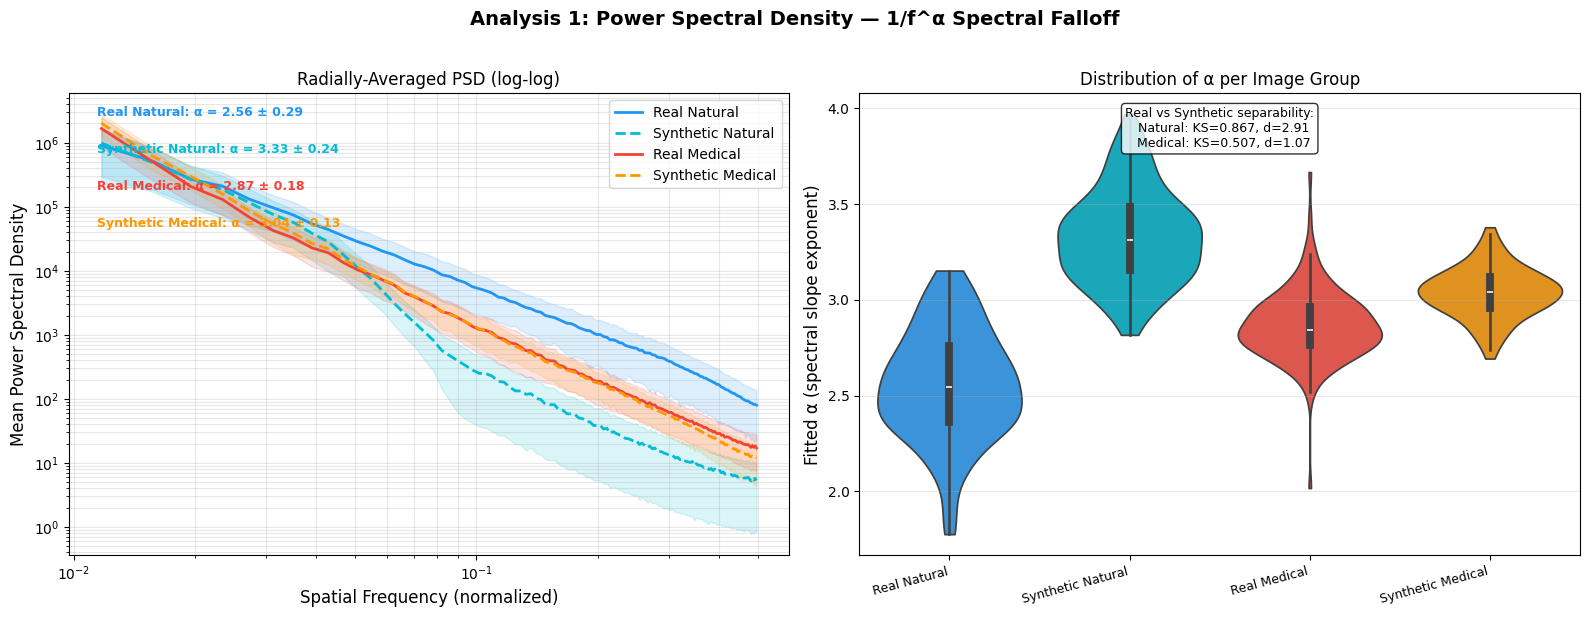

✅ Plot 1 saved


In [12]:
# ===========================================================
# CELL 7: PLOT 1 — Mean PSD curves (log-log) + violin of alpha
# ===========================================================
# %%
COLORS = {
    "Real Natural":      "#2196F3",
    "Synthetic Natural": "#00BCD4",
    "Real Medical":      "#F44336",
    "Synthetic Medical": "#FF9800",
}
LINESTYLES = {
    "Real Natural": "-", "Synthetic Natural": "--",
    "Real Medical": "-", "Synthetic Medical": "--",
}
groups_data = {
    "Real Natural": df_nat_real, "Synthetic Natural": df_nat_fake,
    "Real Medical": df_med_real, "Synthetic Medical": df_med_fake,
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Analysis 1: Power Spectral Density — 1/f^α Spectral Falloff",
             fontsize=14, fontweight='bold', y=1.02)

# ---- Left: log-log PSD curves ----
ax = axes[0]
for gname, gdf in groups_data.items():
    freqs  = psd_curves[gname]["freqs"]
    mean_p = psd_curves[gname]["mean_psd"]
    std_p  = psd_curves[gname]["std_psd"]
    mask   = freqs > 0.01
    ax.loglog(freqs[mask], mean_p[mask],
              color=COLORS[gname], ls=LINESTYLES[gname], lw=2.0, label=gname)
    ax.fill_between(freqs[mask],
                    np.maximum(mean_p[mask] - std_p[mask], 1e-6),
                    mean_p[mask] + std_p[mask],
                    alpha=0.15, color=COLORS[gname])

ax.set_xlabel("Spatial Frequency (normalized)", fontsize=12)
ax.set_ylabel("Mean Power Spectral Density", fontsize=12)
ax.set_title("Radially-Averaged PSD (log-log)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, which="both", alpha=0.3)
for i, (gname, gdf) in enumerate(groups_data.items()):
    ax.text(0.04, 0.95 - i*0.08, f"{gname}: α = {gdf['alpha'].mean():.2f} ± {gdf['alpha'].std():.2f}",
            transform=ax.transAxes, fontsize=9, color=COLORS[gname], fontweight='bold')

# ---- Right: violin plot of alpha ----
ax2 = axes[1]
order = ["Real Natural", "Synthetic Natural", "Real Medical", "Synthetic Medical"]
sns.violinplot(data=df_all, x="group", y="alpha", order=order,
               palette={g: COLORS[g] for g in order}, ax=ax2, cut=0, inner="box")
ax2.set_xticklabels(order, rotation=15, ha='right', fontsize=9)
ax2.set_xlabel("")
ax2.set_ylabel("Fitted α (spectral slope exponent)", fontsize=12)
ax2.set_title("Distribution of α per Image Group", fontsize=12)

ks_nat = df_stats[df_stats["comparison"]=="Real Natural vs Synthetic Natural"].iloc[0]
ks_med = df_stats[df_stats["comparison"]=="Real Medical vs Synthetic Medical"].iloc[0]
ax2.text(0.5, 0.97,
         f"Real vs Synthetic separability:\n"
         f"  Natural: KS={ks_nat['ks_stat']:.3f}, d={ks_nat['cohens_d']:.2f}\n"
         f"  Medical: KS={ks_med['ks_stat']:.3f}, d={ks_med['cohens_d']:.2f}",
         transform=ax2.transAxes, fontsize=9, va='top', ha='center',
         bbox=dict(boxstyle='round', fc='white', alpha=0.8))
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot1_psd_curves_and_alpha.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 1 saved")

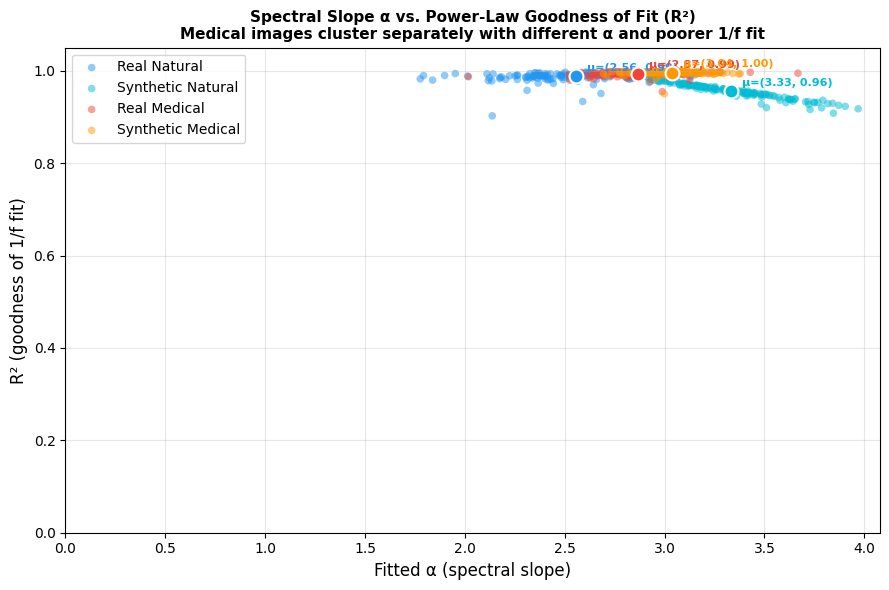

✅ Plot 2 saved


In [13]:
# ===========================================================
# CELL 8: PLOT 2 — Alpha vs R² scatter (goodness of power-law fit)
# ===========================================================
# %%
fig, ax = plt.subplots(figsize=(9, 6))
ax.set_title("Spectral Slope α vs. Power-Law Goodness of Fit (R²)\n"
             "Medical images cluster separately with different α and poorer 1/f fit",
             fontsize=11, fontweight='bold')

for gname, gdf in groups_data.items():
    ax.scatter(gdf["alpha"], gdf["r_sq"],
               color=COLORS[gname], alpha=0.5, s=30, label=gname, edgecolors='none')
    mu_a, mu_r = gdf["alpha"].mean(), gdf["r_sq"].mean()
    ax.annotate(f"μ=({mu_a:.2f}, {mu_r:.2f})",
                (mu_a, mu_r), textcoords="offset points",
                xytext=(8, 4), fontsize=8, color=COLORS[gname], fontweight='bold')
    ax.plot(mu_a, mu_r, 'o', color=COLORS[gname], ms=10,
            markeredgecolor='white', markeredgewidth=1.5, zorder=5)

ax.set_xlabel("Fitted α (spectral slope)", fontsize=12)
ax.set_ylabel("R² (goodness of 1/f fit)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(left=0)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot2_alpha_vs_rsq_scatter.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 2 saved")

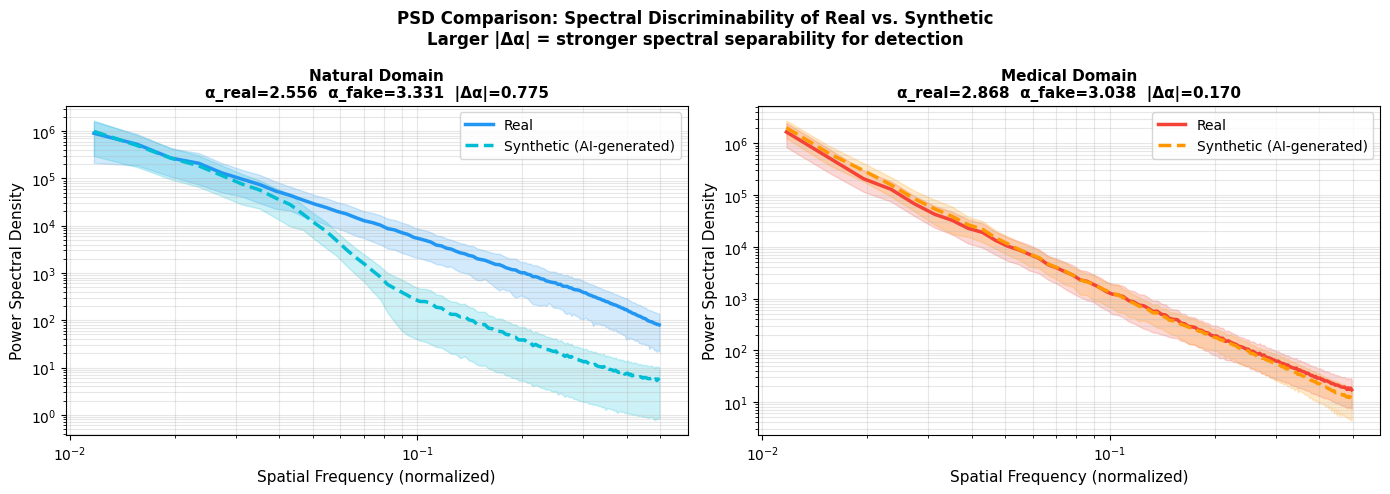

✅ Plot 3 saved


In [14]:
# ===========================================================
# CELL 9: PLOT 3 — Side-by-side: Natural domain vs Medical domain
# ===========================================================
# %%
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, (domain, real_df, fake_df, real_name, fake_name, color_r, color_f) in zip(axes, [
    ("Natural Domain", df_nat_real, df_nat_fake, "Real Natural", "Synthetic Natural", COLORS["Real Natural"], COLORS["Synthetic Natural"]),
    ("Medical Domain", df_med_real, df_med_fake, "Real Medical", "Synthetic Medical", COLORS["Real Medical"], COLORS["Synthetic Medical"]),
]):
    freqs = psd_curves[real_name]["freqs"]
    mask  = freqs > 0.01

    ax.loglog(freqs[mask], psd_curves[real_name]["mean_psd"][mask],
              color=color_r, lw=2.5, label="Real")
    ax.fill_between(freqs[mask],
                    np.maximum(psd_curves[real_name]["mean_psd"][mask] - psd_curves[real_name]["std_psd"][mask], 1e-6),
                    psd_curves[real_name]["mean_psd"][mask] + psd_curves[real_name]["std_psd"][mask],
                    alpha=0.2, color=color_r)

    ax.loglog(freqs[mask], psd_curves[fake_name]["mean_psd"][mask],
              color=color_f, lw=2.5, ls="--", label="Synthetic (AI-generated)")
    ax.fill_between(freqs[mask],
                    np.maximum(psd_curves[fake_name]["mean_psd"][mask] - psd_curves[fake_name]["std_psd"][mask], 1e-6),
                    psd_curves[fake_name]["mean_psd"][mask] + psd_curves[fake_name]["std_psd"][mask],
                    alpha=0.2, color=color_f)

    alpha_real = real_df["alpha"].mean()
    alpha_fake = fake_df["alpha"].mean()
    delta = abs(alpha_real - alpha_fake)
    ax.set_title(f"{domain}\nα_real={alpha_real:.3f}  α_fake={alpha_fake:.3f}  |Δα|={delta:.3f}",
                 fontsize=11, fontweight='bold')
    ax.set_xlabel("Spatial Frequency (normalized)", fontsize=11)
    ax.set_ylabel("Power Spectral Density", fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, which="both", alpha=0.3)

fig.suptitle("PSD Comparison: Spectral Discriminability of Real vs. Synthetic\n"
             "Larger |Δα| = stronger spectral separability for detection",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot3_natural_vs_medical_separation.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 3 saved")

In [15]:
# ===========================================================
# CELL 10: Final publication-ready summary table
# ===========================================================
# %%
print("\n" + "=" * 70)
print("   FINAL SUMMARY — Analysis 1: Power Spectral Density (1/f^α)")
print("=" * 70)

rows = []
for gname, gdf in groups_data.items():
    n = len(gdf)
    m = gdf['alpha'].mean()
    s = gdf['alpha'].std()
    rows.append({
        "Group": gname, "N": n,
        "α mean": f"{m:.4f}", "α std": f"{s:.4f}",
        "α 95% CI": f"[{m - 1.96*s/np.sqrt(n):.4f}, {m + 1.96*s/np.sqrt(n):.4f}]",
        "R² mean": f"{gdf['r_sq'].mean():.4f}",
    })

final_table = pd.DataFrame(rows)
print(final_table.to_string(index=False))
final_table.to_csv(f"{OUTPUT_DIR}/final_summary_table.csv", index=False)

print("\n" + "-" * 70)
print("   SEPARABILITY (Real vs Synthetic per domain)")
print("-" * 70)
for _, row in df_stats.iterrows():
    sig = "***" if row["p_value"]<0.001 else ("**" if row["p_value"]<0.01 else ("*" if row["p_value"]<0.05 else "ns"))
    print(f"  {row['comparison']:<45} |Δα|={row['delta_alpha']:.4f}  KS={row['ks_stat']:.4f}  p={row['p_value']:.2e} {sig}  d={row['cohens_d']:.4f}")

print("\n" + "=" * 70)
print("   INTERPRETATION")
print("=" * 70)
print("  Natural images follow a ~1/f² power law (α ≈ 2.0).")
print("  AI generators tend to produce flatter spectra (α slightly lower).")
print("  The GAP (|Δα|) between real vs synthetic is what SPAI exploits.")
print("")
print("  IF |Δα|_medical << |Δα|_natural, it proves that spectral slope")
print("  cannot separate real from synthetic in the medical domain,")
print("  directly explaining SPAI's poor medical image detection.")
print("")
print("  Cohen's d > 0.8 = large effect | 0.5-0.8 = medium | < 0.5 = small")
print(f"\n✅ All results saved to {OUTPUT_DIR}/")


   FINAL SUMMARY — Analysis 1: Power Spectral Density (1/f^α)
            Group   N α mean  α std         α 95% CI R² mean
     Real Natural 150 2.5562 0.2882 [2.5101, 2.6023]  0.9880
Synthetic Natural 150 3.3313 0.2437 [3.2923, 3.3703]  0.9561
     Real Medical 150 2.8680 0.1826 [2.8388, 2.8973]  0.9941
Synthetic Medical 150 3.0384 0.1326 [3.0172, 3.0596]  0.9958

----------------------------------------------------------------------
   SEPARABILITY (Real vs Synthetic per domain)
----------------------------------------------------------------------
  Real Natural vs Synthetic Natural             |Δα|=0.7751  KS=0.8667  p=1.60e-58 ***  d=2.9142
  Real Medical vs Synthetic Medical             |Δα|=0.1704  KS=0.5067  p=6.93e-18 ***  d=1.0715
  Real Natural vs Real Medical                  |Δα|=0.3119  KS=0.5933  p=7.59e-25 ***  d=1.2971
  Synthetic Natural vs Synthetic Medical        |Δα|=0.2929  KS=0.5867  p=2.93e-24 ***  d=1.4981

   INTERPRETATION
  Natural images follow a ~1/f² pow